In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    OrdinalEncoder, 
    OneHotEncoder, 
    StandardScaler, 
    PolynomialFeatures
)

from sklearn.model_selection import (
    train_test_split,
    cross_validate, 
    StratifiedKFold,
    KFold,
    RandomizedSearchCV
)

# For Regression Tasks
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import RadiusNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# For Classification Tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    make_scorer,
    accuracy_score, 
    confusion_matrix,    
    classification_report,
    mean_squared_error, 
    r2_score,
    mean_absolute_error,
    f1_score
)

In [3]:
RANDOM_STATE = 777

In [4]:
df = pd.read_csv(
    filepath_or_buffer="student_placement_synthetic.csv"
)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

`placement_status` for classification, while `salary_package_lpa` is a regression task.

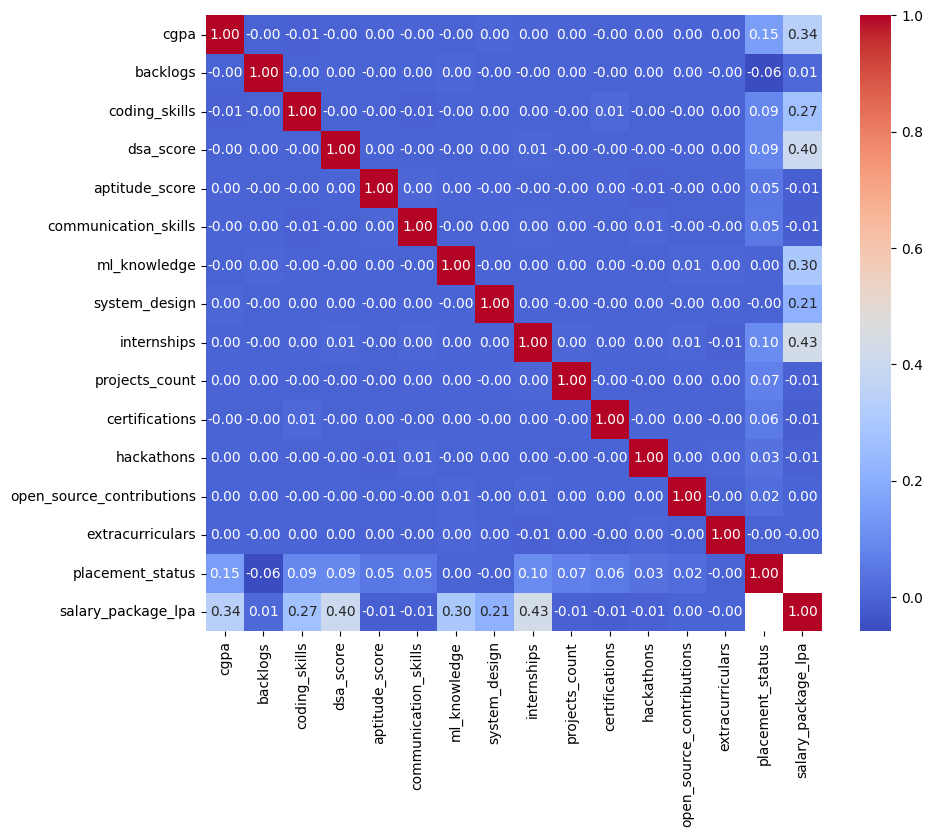

In [6]:
corr = df.corr(
	method='pearson', 
	min_periods=1, 
	numeric_only=True
)


plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.show()

In [7]:
df = df.drop(columns=["open_source_contributions", "extracurriculars", "hackathons"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   branch                100000 non-null  object 
 1   college_tier          100000 non-null  object 
 2   cgpa                  100000 non-null  float64
 3   backlogs              100000 non-null  int64  
 4   coding_skills         100000 non-null  float64
 5   dsa_score             100000 non-null  float64
 6   aptitude_score        100000 non-null  float64
 7   communication_skills  100000 non-null  float64
 8   ml_knowledge          100000 non-null  float64
 9   system_design         100000 non-null  float64
 10  internships           100000 non-null  int64  
 11  projects_count        100000 non-null  int64  
 12  certifications        100000 non-null  int64  
 13  placement_status      100000 non-null  int64  
 14  salary_package_lpa    68475 non-null   float64
dtypes

### Encoding

#### One-hot encoding

In [9]:
onehot_encoder = OneHotEncoder(sparse_output=False)
encoded = onehot_encoder.fit_transform(df[["branch"]])

encoded_df = pd.DataFrame(encoded, columns=onehot_encoder.get_feature_names_out())
df = pd.concat([df, encoded_df], axis=1)

df

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,...,certifications,placement_status,salary_package_lpa,branch_CE,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,...,4,1,14.75,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,...,0,0,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,...,2,1,19.06,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,...,3,0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,...,0,1,13.42,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,...,2,0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,...,3,1,16.58,0.0,0.0,0.0,0.0,0.0,1.0,0.0
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,...,1,1,17.24,0.0,0.0,0.0,0.0,1.0,0.0,0.0
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,...,2,1,17.01,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [10]:
df = df.drop(columns="branch")

#### Ordinal Encoding

In [11]:
ordinal_encoder = OrdinalEncoder(categories=[["Tier-3", "Tier-2", "Tier-1"]])
df["college_tier_encoded"] = ordinal_encoder.fit_transform(df[["college_tier"]])

In [12]:
df

,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,...,placement_status,salary_package_lpa,branch_CE,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME,college_tier_encoded
0,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,...,1,14.75,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,...,0,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,...,1,19.06,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,...,0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,...,1,13.42,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,...,0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
99996,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,...,1,16.58,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
99997,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,...,1,17.24,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
99998,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,...,1,17.01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [13]:
df = df.drop(columns="college_tier")

### Working with `NaN` values

In [14]:
df_regression = df.dropna()

In [15]:
df_regression.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68475 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  68475 non-null  float64
 1   backlogs              68475 non-null  int64  
 2   coding_skills         68475 non-null  float64
 3   dsa_score             68475 non-null  float64
 4   aptitude_score        68475 non-null  float64
 5   communication_skills  68475 non-null  float64
 6   ml_knowledge          68475 non-null  float64
 7   system_design         68475 non-null  float64
 8   internships           68475 non-null  int64  
 9   projects_count        68475 non-null  int64  
 10  certifications        68475 non-null  int64  
 11  placement_status      68475 non-null  int64  
 12  salary_package_lpa    68475 non-null  float64
 13  branch_CE             68475 non-null  float64
 14  branch_CSE            68475 non-null  float64
 15  branch_Chemical       68

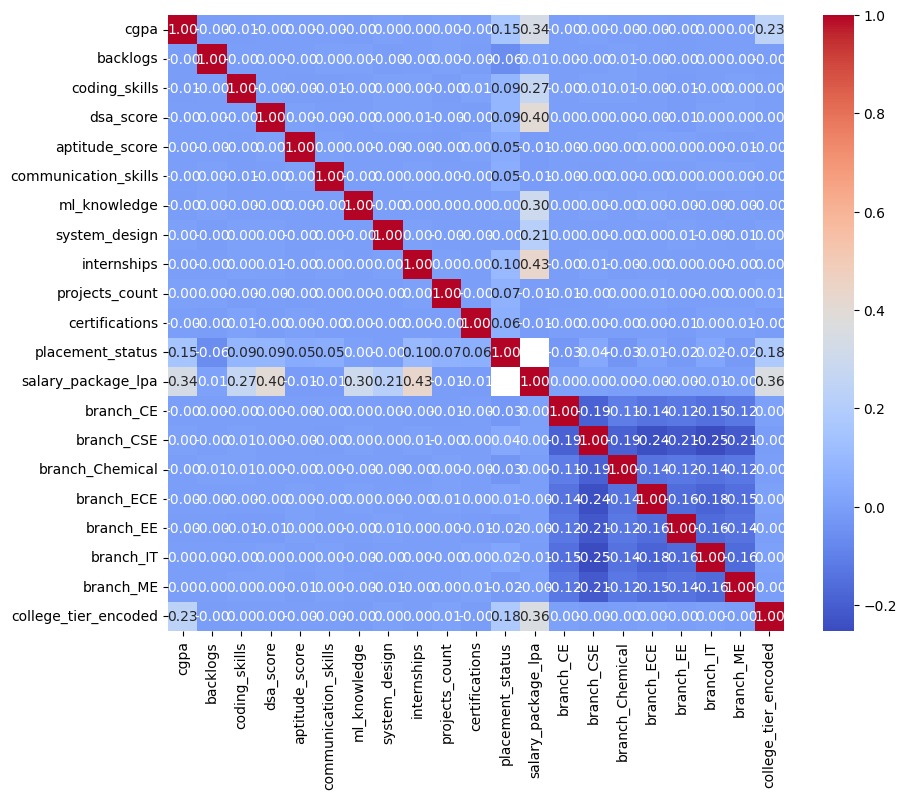

In [16]:
corr = df.corr(
	method='pearson', 
	min_periods=1, 
	numeric_only=True
)


plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.show()

In [17]:
corr.loc[:, "salary_package_lpa"]

cgpa                    0.337110
backlogs                0.007919
coding_skills           0.269022
dsa_score               0.400980
aptitude_score         -0.009342
communication_skills   -0.011931
ml_knowledge            0.300207
system_design           0.212229
internships             0.428622
projects_count         -0.005822
certifications         -0.010933
placement_status             NaN
salary_package_lpa      1.000000
branch_CE               0.004985
branch_CSE              0.004208
branch_Chemical         0.000487
branch_ECE             -0.002728
branch_EE              -0.000643
branch_IT              -0.005265
branch_ME              -0.000943
college_tier_encoded    0.356266
Name: salary_package_lpa, dtype: float64

In [20]:
placement = corr.loc[:, "placement_status"].reset_index()
placement = placement[placement["placement_status"] > 0.05]

placement

,index,placement_status
0,cgpa,0.148932
2,coding_skills,0.087657
3,dsa_score,0.086594
5,communication_skills,0.051034
8,internships,0.099967
9,projects_count,0.069900
10,certifications,0.055636
11,placement_status,1.000000
20,college_tier_encoded,0.180052


In [22]:
salary = corr.loc[:, "salary_package_lpa"].reset_index()
salary = salary[salary["salary_package_lpa"] > 0.0001]

salary

,index,salary_package_lpa
0,cgpa,0.337110
1,backlogs,0.007919
2,coding_skills,0.269022
3,dsa_score,0.400980
6,ml_knowledge,0.300207
7,system_design,0.212229
8,internships,0.428622
12,salary_package_lpa,1.000000
13,branch_CE,0.004985
14,branch_CSE,0.004208


In [23]:
df_regression = df.dropna().loc[:, salary["index"]]
df_classification = df.loc[:, placement["index"]]

df_regression.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68475 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  68475 non-null  float64
 1   backlogs              68475 non-null  int64  
 2   coding_skills         68475 non-null  float64
 3   dsa_score             68475 non-null  float64
 4   ml_knowledge          68475 non-null  float64
 5   system_design         68475 non-null  float64
 6   internships           68475 non-null  int64  
 7   salary_package_lpa    68475 non-null  float64
 8   branch_CE             68475 non-null  float64
 9   branch_CSE            68475 non-null  float64
 10  branch_Chemical       68475 non-null  float64
 11  college_tier_encoded  68475 non-null  float64
dtypes: float64(10), int64(2)
memory usage: 6.8 MB


In [25]:
df_classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   cgpa                  100000 non-null  float64
 1   coding_skills         100000 non-null  float64
 2   dsa_score             100000 non-null  float64
 3   communication_skills  100000 non-null  float64
 4   internships           100000 non-null  int64  
 5   projects_count        100000 non-null  int64  
 6   certifications        100000 non-null  int64  
 7   placement_status      100000 non-null  int64  
 8   college_tier_encoded  100000 non-null  float64
dtypes: float64(5), int64(4)
memory usage: 6.9 MB


## Regression

### Gradient Boosting Regressor

In [112]:
X = df_regression.drop(columns=["salary_package_lpa"])
y = df_regression["salary_package_lpa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [113]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=1.0,
    max_features=None,
    random_state=RANDOM_STATE
)

gradient_boosting.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [114]:
y_pred = gradient_boosting.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)

MAE: 1.5201917242354337
MSE: 0.7777675254526533
rMSE: 1.5201917242354337
R2: 0.7777675254526533


In [115]:
importances = gradient_boosting.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)    


In [116]:
importance_df

,feature,importance
6,internships,0.237163
3,dsa_score,0.209783
10,college_tier_encoded,0.172434
4,ml_knowledge,0.115295
0,cgpa,0.114656
2,coding_skills,0.096635
5,system_design,0.054035
1,backlogs,0.000000
7,branch_CE,0.000000
8,branch_CSE,0.000000


In [117]:
important_features = importance_df[importance_df["importance"] > 0]["feature"]
X = df_regression.drop(columns=["salary_package_lpa"]).loc[:, important_features]
y = df_regression["salary_package_lpa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [118]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=1.0,
    max_features=None,
    random_state=RANDOM_STATE
)

gradient_boosting.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [119]:
y_pred = gradient_boosting.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)

MAE: 1.5201917242354337
MSE: 0.7777675254526533
rMSE: 1.5201917242354337
R2: 0.7777675254526533


### XGBoost Regressor

In [120]:
X = df_regression.drop(columns=["salary_package_lpa"])
y = df_regression["salary_package_lpa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [121]:
xg_boosting = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
) 

xg_boosting.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [122]:
y_pred = xg_boosting.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)

MAE: 1.4704386247154997
MSE: 0.7850407885854835
rMSE: 1.4704386247154997
R2: 0.7850407885854835


In [123]:
importances = xg_boosting.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

important_features = importance_df[importance_df["importance"] > 0]["feature"]
X = df_regression.drop(columns=["salary_package_lpa"]).loc[:, important_features]
y = df_regression["salary_package_lpa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

important_features

10    college_tier_encoded
6              internships
3                dsa_score
4             ml_knowledge
2            coding_skills
0                     cgpa
5            system_design
9          branch_Chemical
8               branch_CSE
7                branch_CE
1                 backlogs
Name: feature, dtype: object

In [124]:
xg_boosting = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
) 

xg_boosting.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [125]:
y_pred = xg_boosting.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)

MAE: 1.4687769293308024
MSE: 0.7852837070749069
rMSE: 1.4687769293308024
R2: 0.7852837070749069


### LightGBM Regressor

In [126]:
X = df_regression.drop(columns=["salary_package_lpa"])
y = df_regression["salary_package_lpa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [127]:
lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002241 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 657
[LightGBM] [Info] Number of data points in the train set: 54780, number of used features: 11
[LightGBM] [Info] Start training from score 17.301460


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [128]:
y_pred = lgbm.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)

MAE: 1.469871888428962
MSE: 0.7851236381401582
rMSE: 1.469871888428962
R2: 0.7851236381401582


In [129]:
param_dist = {
    "n_estimators": [200,400,600],
    "learning_rate": [0.01,0.05,0.1],
    "num_leaves": [31,63,127],
    "subsample": [0.7,0.9],
    "colsample_bytree": [0.7,0.9]
}

search = RandomizedSearchCV(
    LGBMRegressor(),
    param_dist,
    n_iter=25,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

search.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 657
[LightGBM] [Info] Number of data points in the train set: 54780, number of used features: 11
[LightGBM] [Info] Start training from score 17.301460


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.9], 'learning_rate': [0.01, 0.05, ...], 'n_estimators': [200, 400, ...], 'num_leaves': [31, 63, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used 

In [130]:
best_lgbm = search.best_estimator_

y_pred = best_lgbm.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)

MAE: 1.469176900622617
MSE: 0.785225236417219
rMSE: 1.469176900622617
R2: 0.785225236417219


### Cat Boost Regressor

In [131]:
X = df_regression.drop(columns=["salary_package_lpa"])
y = df_regression["salary_package_lpa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [132]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

In [133]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)

MAE: 1.4351234882915218
MSE: 0.7902034072416434
rMSE: 1.4351234882915218
R2: 0.7902034072416434


In [134]:
model.get_feature_importance()

array([1.11385277e+01, 7.89543574e-02, 1.05112801e+01, 2.13687067e+01,
       1.22799399e+01, 5.97029032e+00, 2.22442872e+01, 1.33537087e-02,
       2.29662406e-02, 2.26574359e-02, 1.63490363e+01])

In [135]:
importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

important_features = importance_df[importance_df["importance"] > 0.25]["feature"]
X = df_regression.drop(columns=["salary_package_lpa"]).loc[:, important_features]
y = df_regression["salary_package_lpa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

important_features

6              internships
3                dsa_score
10    college_tier_encoded
4             ml_knowledge
0                     cgpa
2            coding_skills
5            system_design
Name: feature, dtype: object

In [136]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

In [137]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)

MAE: 1.436457909610352
MSE: 0.7900083320106416
rMSE: 1.436457909610352
R2: 0.7900083320106416


### Radius Neighbors Regressor

In [138]:
df_regression.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68475 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  68475 non-null  float64
 1   backlogs              68475 non-null  int64  
 2   coding_skills         68475 non-null  float64
 3   dsa_score             68475 non-null  float64
 4   ml_knowledge          68475 non-null  float64
 5   system_design         68475 non-null  float64
 6   internships           68475 non-null  int64  
 7   salary_package_lpa    68475 non-null  float64
 8   branch_CE             68475 non-null  float64
 9   branch_CSE            68475 non-null  float64
 10  branch_Chemical       68475 non-null  float64
 11  college_tier_encoded  68475 non-null  float64
dtypes: float64(10), int64(2)
memory usage: 6.8 MB


In [139]:
X = df_regression.drop(columns=["salary_package_lpa"])
y = df_regression["salary_package_lpa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [140]:
model = RadiusNeighborsRegressor(
    radius=6.0,
    weights="uniform",
    algorithm="auto",
    leaf_size=30,
    p=2,
    metric="minkowski",
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",6.0
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


In [141]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)

MAE: 6.3308806956834704
MSE: 0.07450668186385034
rMSE: 6.3308806956834704
R2: 0.07450668186385034


### Polynomial Regression

In [142]:
X = df_regression.drop(columns=["salary_package_lpa"])
y = df_regression["salary_package_lpa"]

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Polynomial features can explode in magnitude. Scaling it
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

# Model Training
model = LinearRegression()
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [144]:
y_pred = model.predict(X_test_poly)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)

MAE: 1.4266282375099497
MSE: 0.7914453036241793
rMSE: 1.4266282375099497
R2: 0.7914453036241793


### Random Forest Regression

In [145]:
X = df_regression.drop(columns=["salary_package_lpa"])
y = df_regression["salary_package_lpa"]

In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.6, random_state=RANDOM_STATE
)

In [147]:
rf = RandomForestRegressor(
    n_estimators=100,
    criterion="squared_error",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [148]:
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)
print("OOB Score:", rf.oob_score_)

MAE: 1.6654145929000852
MSE: 0.7559023733915438
rMSE: 1.6654145929000852
R2: 0.7559023733915438
OOB Score: 0.7485684955223584


In [149]:
importances = rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
3,dsa_score,0.196968
6,internships,0.173713
0,cgpa,0.135697
10,college_tier_encoded,0.130367
4,ml_knowledge,0.130065
2,coding_skills,0.112772
5,system_design,0.087391
1,backlogs,0.014541
8,branch_CSE,0.008299
7,branch_CE,0.005114


In [150]:
importance_df = importance_df[importance_df["importance"] > 0.02]
columns_to_keep = importance_df.feature

importance_df

,feature,importance
3,dsa_score,0.196968
6,internships,0.173713
0,cgpa,0.135697
10,college_tier_encoded,0.130367
4,ml_knowledge,0.130065
2,coding_skills,0.112772
5,system_design,0.087391


In [151]:
X = df_regression.drop(columns=["salary_package_lpa"]).loc[:, columns_to_keep]
y = df_regression["salary_package_lpa"]

In [152]:
X.columns

Index(['dsa_score', 'internships', 'cgpa', 'college_tier_encoded',
       'ml_knowledge', 'coding_skills', 'system_design'],
      dtype='object')

In [153]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.6, random_state=RANDOM_STATE
)

rf = RandomForestRegressor(
    n_estimators=100,
    criterion="squared_error",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)
print("OOB Score:", rf.oob_score_)

MAE: 1.6461254181387366
MSE: 0.7587295623681227
rMSE: 1.6461254181387366
R2: 0.7587295623681227
OOB Score: 0.751378864869995


In [154]:
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error, greater_is_better=False),
    "R2": make_scorer(r2_score)
}

cv = KFold(n_splits=10, shuffle=True, random_state=42)

results = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    scores = results["test_" + metric]
    if metric in ["MAE", "MSE"]:
        scores = -scores
    print(f"{metric}: {np.mean(scores)}")

MAE: 1.0036676334779866
MSE: 1.5875637060549297
R2: 0.7652946274822597


### KNN Regressor

In [155]:
X = df_regression.drop(columns=["salary_package_lpa"])
y = df_regression["salary_package_lpa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [156]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [157]:
knn = KNeighborsRegressor(
    n_neighbors=5,
    weights="uniform",      
    algorithm="auto",       
    leaf_size=30,
    p=2,                    
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [158]:
y_pred = knn.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)

MAE: 1.9470383599853962
MSE: 0.7153680382020351
rMSE: 1.9470383599853962
R2: 0.7153680382020351


In [159]:
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error, greater_is_better=False),
    "R2": make_scorer(r2_score)
}

cv = KFold(n_splits=10, shuffle=True, random_state=42)

results = cross_validate(
    knn,
    X,
    y,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    scores = results["test_" + metric]
    if metric in ["MAE", "MSE"]:
        scores = -scores
    print(f"{metric}: {np.mean(scores)}")

MAE: 1.1158206890953675
MSE: 1.9668051959815098
R2: 0.7092179826935356


### Support Vector Regression

In [160]:
X = df_regression.drop(columns=["salary_package_lpa"])
y = df_regression["salary_package_lpa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=RANDOM_STATE
)

In [161]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [162]:
svr = SVR(
    kernel="rbf",      
    C=1.0,
    epsilon=0.1,
    gamma="scale",     
    degree=3,          
    coef0=0.0          
)

svr.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [163]:
y_pred = svr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mse)
print("MSE:", r2)
print("rMSE:", mse)
print("R2:", r2)

MAE: 1.490605225241527
MSE: 0.7811148620638694
rMSE: 1.490605225241527
R2: 0.7811148620638694


In [ ]:
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error, greater_is_better=False),
    "R2": make_scorer(r2_score)
}

cv = KFold(n_splits=10, shuffle=True, random_state=42)

results = cross_validate(
    svr,
    X,
    y,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    scores = results["test_" + metric]
    if metric in ["MAE", "MSE"]:
        scores = -scores
    print(f"{metric}: {np.mean(scores)}")

## Classification Models

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   cgpa                       100000 non-null  float64
 1   backlogs                   100000 non-null  int64  
 2   coding_skills              100000 non-null  float64
 3   dsa_score                  100000 non-null  float64
 4   aptitude_score             100000 non-null  float64
 5   communication_skills       100000 non-null  float64
 6   ml_knowledge               100000 non-null  float64
 7   system_design              100000 non-null  float64
 8   internships                100000 non-null  int64  
 9   projects_count             100000 non-null  int64  
 10  certifications             100000 non-null  int64  
 11  hackathons                 100000 non-null  int64  
 12  open_source_contributions  100000 non-null  int64  
 13  extracurriculars           100

In [27]:
X = df_classification.drop(columns=["placement_status"])
y = df_classification["placement_status"]

X_train, X_test, y_train, y_test = train_test_split(  
	X, y, test_size=0.5, random_state=RANDOM_STATE  
)  

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_scaled = scaler.transform(X)
X_test_scaled = scaler.transform(X_test)

### Gradient Boosting Classifier 

In [28]:
gradient_boosting_cl = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=RANDOM_STATE
)

gradient_boosting_cl.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [29]:
y_pred = gradient_boosting_cl.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.6944
              precision    recall  f1-score   support

           0       0.56      0.16      0.25     15838
           1       0.71      0.94      0.81     34162

    accuracy                           0.69     50000
   macro avg       0.63      0.55      0.53     50000
weighted avg       0.66      0.69      0.63     50000



In [ ]:
scoring = ["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"]

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = cross_validate(
    gradient_boosting_cl,
    X,    
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    print(f"mean_{metric}: {results['test_' + metric].mean():.4f}")

mean_accuracy: 0.6979
mean_f1_weighted: 0.6331
mean_precision_weighted: 0.6675
mean_recall_weighted: 0.6979


### Extreme Gradient Boosting

In [ ]:
xg_boosting_cl = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

xg_boosting_cl.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [ ]:
y_pred = xg_boosting_cl.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.69616
              precision    recall  f1-score   support

           0       0.56      0.20      0.29     15838
           1       0.71      0.93      0.81     34162

    accuracy                           0.70     50000
   macro avg       0.64      0.56      0.55     50000
weighted avg       0.66      0.70      0.64     50000



In [ ]:
scoring = ["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"]

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = cross_validate(
    xg_boosting_cl,
    X,    
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    print(f"mean_{metric}: {results['test_' + metric].mean():.4f}")

mean_accuracy: 0.6983
mean_f1_weighted: 0.6458
mean_precision_weighted: 0.6666
mean_recall_weighted: 0.6983


#### Random Search of Hyperparameters

In [ ]:
param_grid = {
    "n_estimators": np.arange(100, 1200, 100),
    "max_depth": np.arange(3, 12),
    "learning_rate": np.linspace(0.01, 0.3, 30),
    "subsample": np.linspace(0.5, 1.0, 20),
    "colsample_bytree": np.linspace(0.5, 1.0, 20),
    "gamma": np.linspace(0, 5, 30),
    "min_child_weight": np.arange(1, 10)
}

random_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_xgb.fit(X_train, y_train)
best_xgb = random_xgb.best_estimator_

print("Best Parameters:", random_xgb.best_params_)
print("Best CV Score:", random_xgb.best_score_)

Best Parameters: {'subsample': np.float64(0.9473684210526315), 'n_estimators': np.int64(1000), 'min_child_weight': np.int64(5), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.10999999999999997), 'gamma': np.float64(2.413793103448276), 'colsample_bytree': np.float64(0.5789473684210527)}
Best CV Score: 0.69784


In [ ]:
y_pred = best_xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.69614
              precision    recall  f1-score   support

           0       0.56      0.19      0.29     15838
           1       0.71      0.93      0.81     34162

    accuracy                           0.70     50000
   macro avg       0.64      0.56      0.55     50000
weighted avg       0.66      0.70      0.64     50000



### LightGBM

In [ ]:
lgbm_cl = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE
)

lgbm_cl.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 34313, number of negative: 15687
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1034
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.686260 -> initscore=0.782692
[LightGBM] [Info] Start training from score 0.782692


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
y_pred = lgbm_cl.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.6953
              precision    recall  f1-score   support

           0       0.55      0.20      0.29     15838
           1       0.71      0.92      0.81     34162

    accuracy                           0.70     50000
   macro avg       0.63      0.56      0.55     50000
weighted avg       0.66      0.70      0.64     50000



### Cat Boost Classifier

In [ ]:
catboost_cl = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    random_state=RANDOM_STATE,
    verbose=True
)

catboost_cl.fit(X_train, y_train)

0:	learn: 0.6827455	total: 183ms	remaining: 54.7s
1:	learn: 0.6734752	total: 188ms	remaining: 28s
2:	learn: 0.6654425	total: 194ms	remaining: 19.2s
3:	learn: 0.6580975	total: 199ms	remaining: 14.8s
4:	learn: 0.6522164	total: 204ms	remaining: 12s
5:	learn: 0.6458341	total: 210ms	remaining: 10.3s
6:	learn: 0.6403434	total: 214ms	remaining: 8.97s
7:	learn: 0.6356969	total: 220ms	remaining: 8.03s
8:	learn: 0.6309738	total: 226ms	remaining: 7.29s
9:	learn: 0.6266266	total: 232ms	remaining: 6.72s
10:	learn: 0.6230410	total: 237ms	remaining: 6.24s
11:	learn: 0.6196375	total: 244ms	remaining: 5.84s
12:	learn: 0.6163794	total: 249ms	remaining: 5.5s
13:	learn: 0.6134000	total: 255ms	remaining: 5.2s
14:	learn: 0.6108717	total: 261ms	remaining: 4.95s
15:	learn: 0.6085048	total: 266ms	remaining: 4.72s
16:	learn: 0.6063900	total: 272ms	remaining: 4.53s
17:	learn: 0.6043226	total: 278ms	remaining: 4.35s
18:	learn: 0.6025668	total: 284ms	remaining: 4.2s
19:	learn: 0.6010749	total: 289ms	remaining: 4.0

In [ ]:
y_pred = catboost_cl.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.69732
              precision    recall  f1-score   support

           0       0.57      0.19      0.28     15838
           1       0.71      0.93      0.81     34162

    accuracy                           0.70     50000
   macro avg       0.64      0.56      0.54     50000
weighted avg       0.67      0.70      0.64     50000



### Simple Logistic Regression

In [ ]:
logistic_regression = LogisticRegression(
    C=0.7,
    solver="lbfgs",
    max_iter=5000,
    l1_ratio=0
)

logistic_regression.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.7
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [ ]:
y_pred = logistic_regression.predict(X_test_scaled)  
  
print("Accuracy:", accuracy_score(y_test, y_pred))  
print(classification_report(y_test, y_pred))

Accuracy: 0.69915
              precision    recall  f1-score   support

           0       0.57      0.20      0.30      6340
           1       0.72      0.93      0.81     13660

    accuracy                           0.70     20000
   macro avg       0.64      0.57      0.55     20000
weighted avg       0.67      0.70      0.65     20000



In [ ]:
logistic_regression = LogisticRegression(
    C=0.7,
    solver="lbfgs",
    max_iter=5000,
    l1_ratio=0
)

scoring = ["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"]

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = cross_validate(
    logistic_regression,
    X_scaled,    
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    print(f"mean_{metric}: {results['test_' + metric].mean():.4f}")

mean_accuracy: 0.7005
mean_f1_weighted: 0.6494
mean_precision_weighted: 0.6706
mean_recall_weighted: 0.7005


#### Randomized Logistic Regression

In [ ]:
param_grid = {
    "C": np.linspace(start=0.001, stop=1, num=30),
    "solver": ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    "max_iter": [num for num in range(100, 5000, 250)]
}

random_logistic_regression = RandomizedSearchCV(
    estimator=LogisticRegression(),
    param_distributions=param_grid,
    n_iter=20,               # number of random combinations
    cv=5,
    scoring="accuracy",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_logistic_regression.fit(X_train_scaled, y_train)

print("Best Parameters:", random_logistic_regression.best_params_)
print("Best CV Score:", random_logistic_regression.best_score_)

Best Parameters: {'solver': 'newton-cg', 'max_iter': 850, 'C': np.float64(0.035448275862068966)}
Best CV Score: 0.7007375


In [ ]:
best_logistic_regression = random_logistic_regression.best_estimator_
y_pred = best_logistic_regression.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.69935


In [ ]:
importances = np.abs(best_logistic_regression.coef_[0])
feature_importance = pd.Series(importances, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)  
print(feature_importance)

college_tier_encoded         0.374120
cgpa                         0.265753
internships                  0.235612
coding_skills                0.214455
dsa_score                    0.208432
projects_count               0.161676
certifications               0.133036
communication_skills         0.126424
backlogs                     0.125794
aptitude_score               0.109668
hackathons                   0.082962
branch_CSE                   0.067786
branch_Chemical              0.057693
open_source_contributions    0.055043
branch_CE                    0.048186
branch_IT                    0.046801
branch_ME                    0.036873
branch_EE                    0.027159
branch_ECE                   0.016598
extracurriculars             0.016092
system_design                0.011615
ml_knowledge                 0.006082
dtype: float64


In [ ]:
important_features = feature_importance[feature_importance > 0.15].index
print(important_features)
X_train_selected = X_train[important_features]
X_test_selected = X_test[important_features]

Index(['college_tier_encoded', 'cgpa', 'internships', 'coding_skills',
       'dsa_score', 'projects_count'],
      dtype='object')


In [ ]:
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected) # ← transform only!

logistic_regression = LogisticRegression(
    C=np.float64(0.035448275862068966),
    max_iter=850,
    solver='newton-cg'
)

print("Randomized Logistic Regression...")
logistic_regression.fit(X_train_scaled, y_train)

y_pred = logistic_regression.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

Randomized Logistic Regression...
Accuracy: 0.6924


#### Simple KNN

In [ ]:
X = df.drop(columns=["placement_status", "salary_package_lpa"])
y = df["placement_status"]

X_train, X_test, y_train, y_test = train_test_split(  
	X, y, test_size=0.2, random_state=RANDOM_STATE  
)  

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_scaled = scaler.transform(X)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="minkowski",
    p=2
)

model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report: \n", classification_report(y_test, y_pred))

Accuracy: 0.64495
Classification Report: 
               precision    recall  f1-score   support

           0       0.41      0.28      0.33      6340
           1       0.71      0.82      0.76     13660

    accuracy                           0.64     20000
   macro avg       0.56      0.55      0.54     20000
weighted avg       0.61      0.64      0.62     20000



#### Randomized KNN

In [ ]:
# param_grid = {
#     "n_neighbors": list(range(3, 25)),
#     "weights": ["uniform", "distance"],
#     "p": [1, 2, 3],
#     "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute']
# }

# random_knn = RandomizedSearchCV(
#     estimator=KNeighborsClassifier(),
#     param_distributions=param_grid,
#     n_iter=5,                          # number of random combinations
#     cv=5,
#     scoring="accuracy",
#     random_state=RANDOM_STATE,
#     n_jobs=-1
# )

# random_knn.fit(X_train_scaled, y_train)

# print("Best Parameters (Random):", random_knn.best_params_)

# best_knn = random_knn.best_estimator_
# y_pred = best_knn.predict(X_test_scaled)
# print("Accuracy:", accuracy_score(y_test, y_pred))

#### Simple Random Forest

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report: \n", classification_report(y_test, y_pred))

Accuracy: 0.69355
Classification Report: 
               precision    recall  f1-score   support

           0       0.54      0.18      0.27      6305
           1       0.71      0.93      0.81     13695

    accuracy                           0.69     20000
   macro avg       0.63      0.55      0.54     20000
weighted avg       0.66      0.69      0.64     20000



In [ ]:
scoring = ["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"]

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = cross_validate(
    rf,
    X,    
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    print(f"mean_{metric}: {results['test_' + metric].mean():.4f}")

mean_accuracy: 0.6934
mean_f1_weighted: 0.6372
mean_precision_weighted: 0.6576
mean_recall_weighted: 0.6934


In [ ]:
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
0,cgpa,0.115432
4,aptitude_score,0.103341
3,dsa_score,0.095060
6,ml_knowledge,0.093517
2,coding_skills,0.093424
7,system_design,0.092112
5,communication_skills,0.090937
9,projects_count,0.039122
10,certifications,0.035604
13,extracurriculars,0.035101


In [ ]:
threshold = 0.05

selected_features = feature_importance[feature_importance["importance"] > threshold]
feature_names = selected_features["feature"]
print(feature_names)

X_train_selected = X_train[feature_names]
X_test_selected = X_test[feature_names]

0                    cgpa
4          aptitude_score
3               dsa_score
6            ml_knowledge
2           coding_skills
7           system_design
5    communication_skills
Name: feature, dtype: object


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train_selected, y_train)

y_pred = rf.predict(X_test_selected)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.67465


In [ ]:
scoring = ["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"]

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = cross_validate(
    rf,
    X,    
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    print(f"mean_{metric}: {results['test_' + metric].mean():.4f}")

mean_accuracy: 0.6934
mean_f1_weighted: 0.6372
mean_precision_weighted: 0.6576
mean_recall_weighted: 0.6934
